# Baseline Run Evaluation

This notebook compares the long-term baseline run and the target baseline run against available observations. It is designed to mirror the existing streamflow evaluation workflow while adding:

- optional linear-reservoir routing before streamflow comparison
- ET and SWE comparison against observation time series
- soil moisture and groundwater baseflow diagnostics
- user-defined time windows for plotting

In [28]:
import sys
from pathlib import Path
import os
# change to CONFLUENCE root directory
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / 'CONFLUENCE.py').exists():
    pass
elif (PROJECT_ROOT.parent / 'CONFLUENCE.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError('Run this notebook from the CONFLUENCE repository or one of its subfolders.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.custom import linear_reservoir

%matplotlib inline
plt.style.use('default')

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro


## Configuration

Set the config and experiment workspace first. If the baseline files are left as `None`, the notebook will try to detect them from the experiment directory.

In [37]:
EXPERIMENT_DIR = Path('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260331_bigBuckt')
CONFIG_PATH = EXPERIMENT_DIR / 'config_20260331_101738.yaml'

LONGTERM_BASELINE_FILE = None
TARGET_BASELINE_FILE = None
TARGET_YEAR = 2021

OBS_STREAMFLOW_CSV = None
OBS_ET_CSV = None
USE_OPENET_MULTI_MODEL_ENVELOPE = True
OPENET_MULTI_MODEL_CSV = "openet_et_East_River_lumped_HRUs_GRUs_2012-10-01_2022-09-30.csv"
OBS_SWE_CSV = None
ET_COLUMN = 'et'
SWE_COLUMN = 'SWE'
ET_CLIP_START = '2015-10-01'

# ============================================================
# Linear reservoir routing
# ============================================================
USE_LINEAR_RESERVOIR = False

# Calibration objective for the linear reservoir optimizer
RESERVOIR_METRIC = 'nse'  # 'nse', 'kge', or 'log_nse'

# How to choose the final reservoir parameters:
# - 'manual':            use RESERVOIR_PARAMS directly, no optimization at all
# - 'auto':              use RESERVOIR_PARAMS directly (skip re-optimization),
#                        unless RESERVOIR_USE_PARAMS_AS_START=True
# - 'best_of_candidates': run the optimizer AND score RESERVOIR_PARAMS on the
#                        same window, then keep whichever scores higher
RESERVOIR_SELECTION_MODE = 'best_of_candidates'

# If True, RESERVOIR_PARAMS is also passed as an optimizer seed in addition to
# being a scored candidate.  If False, RESERVOIR_PARAMS is only used as-is.
RESERVOIR_USE_PARAMS_AS_START = True

# RESERVOIR_PARAMS: the fixed/manual candidate parameter set.
# Loaded from best_parameters.csv if available; otherwise falls back to hardcoded defaults.
# Set to None to skip the manual candidate entirely and rely solely on the optimizer.
if "best_parameters.csv" in os.listdir(EXPERIMENT_DIR / "settings"):
    best_params_df = pd.read_csv(EXPERIMENT_DIR / "settings" / "best_parameters.csv", index_col=0)
    if not all(param in best_params_df.index for param in ['k_fast', 'k_slow', 'f_fast']):
        print("best_parameters.csv found but missing required parameters. Using defaults")
        RESERVOIR_PARAMS = {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95},
    else:
        RESERVOIR_PARAMS = {
            'k_fast': best_params_df.loc['k_fast']['value'],
            'k_slow': best_params_df.loc['k_slow']['value'],
            'f_fast': best_params_df.loc['f_fast']['value'],
        }
    # Fallback optimizer seed when best_parameters.csv is present but we still want fresh exploration
    RESERVOIR_START_POINTS = [
        {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95},
    ]
else:
    RESERVOIR_PARAMS = {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95}
    RESERVOIR_START_POINTS = [
        {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95},
    ]
RESERVOIR_PARAMS = {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95}  # uncomment to skip manual candidate and rely solely on optimizer

# Additional optimizer seeds: list of dicts with k_fast/k_slow/f_fast, or None.
# These are passed to the optimizer as extra starting points in addition to RESERVOIR_PARAMS
# (when RESERVOIR_USE_PARAMS_AS_START=True).

RESERVOIR_OPT_STRATEGY = 'adaptive'
RESERVOIR_OPT_STARTS = 200
RESERVOIR_OPT_SEED = 42

# ============================================================
# Evaluation windows
# ============================================================
METRIC_WINDOWS = {
    'Long-term baseline': {'label': 'Long-term window', 'start': '2011-10-01', 'end': '2020-09-30'},
    'Target baseline':    {'label': 'WY2021',           'start': '2020-10-01', 'end': '2021-09-30'},
}

# Calibration window for the reservoir optimizer.
# Set to None to use CALIBRATION_PERIOD from the experiment YAML automatically.
# Set an explicit dict to override: {'start': 'YYYY-MM-DD', 'end': 'YYYY-MM-DD'}
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)
RESERVOIR_CAL_WINDOW = {'start': config["CALIBRATION_PERIOD"].split(', ')[0],
                        'end':   config["CALIBRATION_PERIOD"].split(', ')[1]}

# ============================================================
# Plot controls
# ============================================================
# Set to None to plot all available runs, or restrict to a subset:
# PLOT_RUNS = ['Long-term baseline']
PLOT_RUNS = ['Long-term baseline']

PLOT_WINDOWS = [
    {'label': 'WY2010-2020', 'start': '2011-10-01', 'end': '2020-09-30'},
    # {'label': 'Snowmelt 2021', 'start': '2021-03-01', 'end': '2021-07-31'},
]

print(f'Config: {CONFIG_PATH}')
print(f'Experiment dir: {EXPERIMENT_DIR}')
print(f'Use linear reservoir: {USE_LINEAR_RESERVOIR}')
print(f'ET clip start: {ET_CLIP_START}')
print(f'Metric windows: {METRIC_WINDOWS}')
print(f'Reservoir calibration window override: {RESERVOIR_CAL_WINDOW}')
print(f'Reservoir metric: {RESERVOIR_METRIC}')
print(f'Reservoir selection mode: {RESERVOIR_SELECTION_MODE}')
print(f'Reservoir optimizer strategy: {RESERVOIR_OPT_STRATEGY}, starts={RESERVOIR_OPT_STARTS}, seed={RESERVOIR_OPT_SEED}')
print(f'Reservoir params fixed/manual input: {RESERVOIR_PARAMS}')
print(f'Reservoir use params as start: {RESERVOIR_USE_PARAMS_AS_START}')
print(f'Reservoir start points: {RESERVOIR_START_POINTS}')
print(f'Plot runs: {PLOT_RUNS if PLOT_RUNS is not None else "all"}')
print(f'Plot windows: {PLOT_WINDOWS}')

Config: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260331_bigBuckt/config_20260331_101738.yaml
Experiment dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260331_bigBuckt
Use linear reservoir: False
ET clip start: 2015-10-01
Metric windows: {'Long-term baseline': {'label': 'Long-term window', 'start': '2011-10-01', 'end': '2020-09-30'}, 'Target baseline': {'label': 'WY2021', 'start': '2020-10-01', 'end': '2021-09-30'}}
Reservoir calibration window override: {'start': '2003-10-01', 'end': '2010-09-30'}
Reservoir metric: nse
Reservoir selection mode: best_of_candidates
Reservoir optimizer strategy: adaptive, starts=200, seed=42
Reservoir params fixed/manual input: {'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95}
Reservoir use params as start: True
Reservoir start points: [{'k_fast': 0.2, 'k_slow': 0.015, 'f_fast': 0.95}]
Plot runs: ['Long-term baseline']
Plot windows: [{'label': 'WY2010-2020', 'start': '2011-10-01', 'end': '2020-

In [48]:
def load_config(config_path):
    config_path = Path(config_path)
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)


def resolve_project_dir(cfg):
    data_dir = Path(cfg['CONFLUENCE_DATA_DIR']).expanduser()
    return data_dir / f"domain_{cfg['DOMAIN_NAME']}"


def resolve_shapefile(cfg, project_dir):
    catchment_path = cfg.get('CATCHMENT_PATH', 'default')
    catchment_name = cfg.get('CATCHMENT_SHP_NAME', 'default')

    if catchment_path == 'default':
        shp_dir = project_dir / 'shapefiles' / 'catchment'
    else:
        shp_dir = Path(catchment_path).expanduser()

    if catchment_name == 'default':
        shp_name = f"{cfg['DOMAIN_NAME']}_HRUs_GRUs.shp"
    else:
        shp_name = catchment_name

    shp_path = shp_dir / shp_name
    if not shp_path.exists():
        alt = sorted((project_dir / 'shapefiles' / 'catchment').glob('*.shp'))
        if alt:
            shp_path = alt[0]
    if not shp_path.exists():
        raise FileNotFoundError(f'Catchment shapefile not found: {shp_path}')
    return shp_path


def compute_basin_area_m2(cfg, project_dir):
    # Use HRUarea from SUMMA's attributes.nc — this is the area SUMMA uses
    # internally for runoff calculations, so it must be used here for a
    # unit-consistent discharge conversion.  The catchment shapefile may
    # cover a different or larger extent and MUST NOT be used for this.
    settings_dir = project_dir / 'settings' / 'SUMMA'
    attrs_file = settings_dir / cfg.get('SETTINGS_SUMMA_ATTRIBUTES', 'attributes.nc')
    if attrs_file.exists():
        attrs_ds = xr.open_dataset(attrs_file)
        if 'HRUarea' in attrs_ds:
            area = float(attrs_ds['HRUarea'].sum())
            attrs_ds.close()
            return area, attrs_file
        attrs_ds.close()
    # Fallback: shapefile area (may differ from SUMMA's internal area)
    import warnings
    warnings.warn(f'attributes.nc not found at {attrs_file}; falling back to shapefile area — verify this matches SUMMA')
    shp_path = resolve_shapefile(cfg, project_dir)
    gdf = gpd.read_file(shp_path)
    if gdf.crs is None:
        raise ValueError(f'Shapefile has no CRS: {shp_path}')
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs('EPSG:32613')
    return float(gdf.geometry.area.sum()), shp_path


def find_first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None


def detect_baseline_files(experiment_dir, target_year, allow_missing_target=False):
    experiment_dir = Path(experiment_dir)
    if not experiment_dir.exists():
        raise FileNotFoundError(f'Experiment directory not found: {experiment_dir}')

    longterm_candidates = [
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'baseline_longterm_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_longterm' / 'longterm_baseline_timestep.nc',
    ]
    target_candidates = [
        experiment_dir / 'ensemble' / 'results' / 'baseline' / f'target_wy_{target_year}_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_target' / f'target_wy_{target_year}_timestep.nc',
        experiment_dir / 'ensemble' / 'results' / 'baseline_target' / f'target_year_{target_year}_timestep.nc',
    ]

    longterm_path = find_first_existing(longterm_candidates)
    target_path = find_first_existing(target_candidates)

    if longterm_path is None:
        matches = sorted((experiment_dir / 'ensemble' / 'results').rglob('*baseline*_*timestep.nc'))
        for match in matches:
            if 'longterm' in match.name or 'baseline_longterm' in match.name:
                longterm_path = match
                break

    if target_path is None:
        matches = sorted((experiment_dir / 'ensemble' / 'results').rglob('*target*_*timestep.nc'))
        if matches:
            target_path = matches[0]

    if longterm_path is None:
        raise FileNotFoundError('Could not detect the long-term baseline file from the experiment directory.')
    if target_path is None and not allow_missing_target:
        raise FileNotFoundError('Could not detect the target baseline file from the experiment directory.')

    return longterm_path, target_path


def autodetect_streamflow_csv(project_dir, domain_name):
    direct = project_dir / 'observations' / 'streamflow' / 'preprocessed' / f'{domain_name}_streamflow_processed.csv'
    if direct.exists():
        return direct
    candidates = sorted((project_dir / 'observations' / 'streamflow' / 'preprocessed').glob('*_streamflow_processed.csv'))
    return candidates[0] if candidates else None


def autodetect_et_csv(project_dir):
    et_dir = project_dir / 'observations' / 'et'
    if not et_dir.exists():
        return None
    patterns = ['*openet_East*.csv', '*et*.csv']
    for pattern in patterns:
        matches = sorted(et_dir.glob(pattern))
        if matches:
            return matches[0]
    return None

def _detect_time_col(df):
    for c in ["date", "datetime", "time", "Date", "DATE"]:
        if c in df.columns:
            return c
    raise KeyError("No time column found in OpenET multi-model CSV.")

def load_openet_multimodel_envelope(csv_path, monthly=True):
    """
    Returns DataFrame indexed by time with:
      et_mean, et_min, et_max, n_members
    """
    df = pd.read_csv(csv_path)
    time_col = _detect_time_col(df)
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.set_index(time_col).sort_index()

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise ValueError(f"No numeric ET/model columns found in {csv_path}")

    # Prefer individual model columns; exclude explicit ensemble column from min/max range if present
    member_cols = [c for c in numeric_cols if "ensemble" not in c.lower()]
    if not member_cols:
        member_cols = numeric_cols

    work = df[member_cols].copy()
    if monthly:
        work = work.resample("MS").mean()

    out = pd.DataFrame(index=work.index)
    out["et_mean"] = work.mean(axis=1)
    out["et_min"] = work.min(axis=1)
    out["et_max"] = work.max(axis=1)
    out["n_members"] = work.notna().sum(axis=1)
    return out

def autodetect_swe_csv(project_dir):
    snow_dir = project_dir / 'observations' / 'snow'
    if not snow_dir.exists():
        return None
    patterns = ['*sntl*.csv', '*SNTL*.csv', '*.csv']
    for pattern in patterns:
        matches = sorted(snow_dir.glob(pattern))
        if matches:
            return matches[0]
    return None


def choose_first_numeric_column(df, preferred=None):
    if preferred and preferred in df.columns:
        return preferred
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise ValueError('No numeric data columns found.')
    return numeric_cols[0]


def load_observed_series(csv_path, preferred_column=None, time_col='datetime', monthly=False):
    df = pd.read_csv(csv_path, parse_dates=[time_col])
    df = df.set_index(time_col).sort_index()
    column = choose_first_numeric_column(df, preferred_column)
    series = df[column].copy()
    if monthly:
        if pd.infer_freq(series.index) not in {'MS', 'ME'}:
            series = series.resample('MS').mean()
    return series


def normalize_windows(windows, fallback_start, fallback_end):
    if windows:
        return windows
    return [{'label': 'Full overlap', 'start': str(fallback_start.date()), 'end': str(fallback_end.date())}]


def get_overlap_start_end(obs_series, sim_series_dict):
    starts = [obs_series.index.min()]
    ends = [obs_series.index.max()]
    for series in sim_series_dict.values():
        starts.append(series.index.min())
        ends.append(series.index.max())
    return max(starts), min(ends)


def clip_to_window(series, start, end):
    if series is None:
        return None
    return series.loc[pd.Timestamp(start):pd.Timestamp(end)]


def align_series(obs_series, sim_series):
    joined = pd.concat([obs_series.rename('obs'), sim_series.rename('sim')], axis=1).dropna()
    return joined['obs'], joined['sim']


def compute_streamflow_metrics(obs_series, sim_series):
    obs_aligned, sim_aligned = align_series(obs_series, sim_series)
    if len(obs_aligned) == 0:
        raise ValueError('No overlapping observations and simulations for metric calculation.')

    rmse = float(np.sqrt(np.mean((sim_aligned - obs_aligned) ** 2)))
    bias = float((sim_aligned - obs_aligned).mean())
    pbias = float(100.0 * bias / obs_aligned.mean()) if obs_aligned.mean() != 0 else np.nan
    corr = float(obs_aligned.corr(sim_aligned))
    denom = float(((obs_aligned - obs_aligned.mean()) ** 2).sum())
    nse = float(1.0 - (((obs_aligned - sim_aligned) ** 2).sum() / denom)) if denom != 0 else np.nan

    obs_std = float(obs_aligned.std())
    sim_std = float(sim_aligned.std())
    obs_mean = float(obs_aligned.mean())
    sim_mean = float(sim_aligned.mean())
    if obs_std == 0 or obs_mean == 0:
        kge = np.nan
    else:
        alpha = sim_std / obs_std
        beta = sim_mean / obs_mean
        kge = float(1.0 - np.sqrt((corr - 1.0) ** 2 + (alpha - 1.0) ** 2 + (beta - 1.0) ** 2))

    peak_month_obs = int(obs_aligned.groupby(obs_aligned.index.month).mean().idxmax())
    peak_month_sim = int(sim_aligned.groupby(sim_aligned.index.month).mean().idxmax())
    lognse = float(linear_reservoir.log_nse(obs_aligned.values, sim_aligned.values))

    return {
        'n_points': int(len(obs_aligned)),
        'rmse_cms': rmse,
        'bias_cms': bias,
        'pbias_pct': pbias,
        'corr': corr,
        'nse': nse,
        'kge': kge,
        'log_nse': lognse,
        'peak_month_obs': peak_month_obs,
        'peak_month_sim': peak_month_sim,
    }


def runoff_to_discharge(ds, basin_area_m2, use_linear_reservoir=False,):
    if use_linear_reservoir:
        runoff = ds['averageInstantRunoff'].squeeze().to_pandas()
    elif 'scalarTotalRunoff' in ds:
        runoff = ds['scalarTotalRunoff'].squeeze().to_pandas()
    elif 'averageInstantRunoff' in ds:
        runoff = ds['averageInstantRunoff'].squeeze().to_pandas()
    else:
        raise KeyError("No runoff variable found. Expected 'scalarTotalRunoff' or 'averageInstantRunoff'.")
    runoff.index = pd.to_datetime(runoff.index)
    return runoff * basin_area_m2


def apply_linear_reservoir(discharge_series, params):
    routed = linear_reservoir.two_reservoir_daily(
        q_in=discharge_series.values,
        k_fast=params['k_fast'],
        k_slow=params['k_slow'],
        f=params['f_fast'],
    )
    return pd.Series(routed, index=discharge_series.index, name=discharge_series.name)


def calibrate_reservoir_params(raw_daily, obs_daily, metric, window=None, start_points=None, strategy='adaptive', n_starts=300, seed=42):
    if window is not None:
        raw_daily = clip_to_window(raw_daily, window['start'], window['end'])
        obs_daily = clip_to_window(obs_daily, window['start'], window['end'])
    obs_aligned, sim_aligned = align_series(obs_daily, raw_daily)
    results = linear_reservoir.calibrate_reservoirs(
        q_in=sim_aligned.values,
        obs=obs_aligned.values,
        metric=metric,
        start_points=start_points,
        strategy=strategy,
        n_starts=n_starts,
        seed=seed,
    )
    return {
        'k_fast': float(results['k_fast']),
        'k_slow': float(results['k_slow']),
        'f_fast': float(results['f_fast']),
        'metric': metric,
        'nse': float(results['nse']),
        'kge': float(results['kge']),
        'log_nse': float(results['log_nse']),
        'strategy': results.get('strategy'),
        'objective': float(results.get('objective', np.nan)),
        'n_starts_used': int(results.get('n_starts_used', n_starts)),
        'seeded_starts_used': int(results.get('seeded_starts_used', 0)),
    }


def get_et_series(ds):
    if 'scalarTotalET' in ds:
        # scalarTotalET is in kg/m^2/s, which is equivalent to mm/s of water depth.
        series = -(ds['scalarTotalET']+ds['scalarSnowSublimation']).squeeze().to_pandas() * 3600.0
        series = series.resample('MS').sum()
    elif 'scalarLatHeatTotal' in ds:
        latent_heat_vap = 2.45e6
        series = -ds['scalarLatHeatTotal'].squeeze().to_pandas() * 3600.0 / latent_heat_vap
        series = series.resample('MS').sum()
    else:
        return None
    series.index = pd.to_datetime(series.index)
    return series


def get_swe_series(ds):
    if 'scalarSWE' not in ds:
        return None
    series = ds['scalarSWE'].squeeze().to_pandas()
    series.index = pd.to_datetime(series.index)
    return series.resample('D').mean()


def get_soil_moisture_series(ds):
    if 'scalarTotalSoilLiq' not in ds:
        return None
    total = ds['scalarTotalSoilLiq'].squeeze()
    if 'scalarTotalSoilIce' in ds:
        total = total + ds['scalarTotalSoilIce'].squeeze()
    series = total.to_pandas()
    series.index = pd.to_datetime(series.index)
    return series.resample('D').mean()

def get_aquifer_storage_series(ds):
    if 'scalarAquiferStorage_mean' not in ds:
        return None
    series = ds['scalarAquiferStorage_mean'].squeeze().to_pandas()
    series.index = pd.to_datetime(series.index)
    return series.resample('D').mean()

def get_aquifer_recharge_series(ds):
    if 'scalarAquiferRecharge' not in ds:
        return None
    series = ds['scalarAquiferRecharge'].squeeze().to_pandas()
    series.index = pd.to_datetime(series.index)
    return series.resample('D').mean()

def get_baseflow_series(ds):
    if 'scalarAquiferBaseflow' in ds:
        series = ds['scalarAquiferBaseflow'].squeeze().to_pandas() * 86400.0 * 1000.0
    elif 'scalarSoilBaseflow' in ds:
        series = ds['scalarSoilBaseflow'].squeeze().to_pandas() * 86400.0 * 1000.0
    else:
        return None
    series.index = pd.to_datetime(series.index)
    return series.resample('D').mean()

In [49]:
cfg = load_config(CONFIG_PATH)
project_dir = resolve_project_dir(cfg)
domain_name = cfg['DOMAIN_NAME']
basin_area_m2, shapefile_path = compute_basin_area_m2(cfg, project_dir)

def resolve_effective_calibration_window(cfg, user_window):
    if user_window is not None:
        return user_window, 'manual override'
    period = cfg.get('CALIBRATION_PERIOD', None)
    if isinstance(period, (list, tuple)) and len(period) == 2:
        start = str(pd.Timestamp(period[0]).date())
        end = str(pd.Timestamp(period[1]).date())
        return {'start': start, 'end': end}, 'yaml CALIBRATION_PERIOD'
    return None, 'none (fallback to overlap)'

RESERVOIR_CAL_WINDOW_EFFECTIVE, reservoir_cal_window_source = resolve_effective_calibration_window(
    cfg,
    RESERVOIR_CAL_WINDOW,
    )

if LONGTERM_BASELINE_FILE is None or TARGET_BASELINE_FILE is None:
    auto_longterm, auto_target = detect_baseline_files(EXPERIMENT_DIR, TARGET_YEAR, allow_missing_target=True)
    longterm_file = auto_longterm if LONGTERM_BASELINE_FILE is None else Path(LONGTERM_BASELINE_FILE)
    target_file = auto_target if TARGET_BASELINE_FILE is None else Path(TARGET_BASELINE_FILE)
else:
    longterm_file = Path(LONGTERM_BASELINE_FILE)
    target_file = Path(TARGET_BASELINE_FILE)

obs_streamflow_path = Path(OBS_STREAMFLOW_CSV) if OBS_STREAMFLOW_CSV else autodetect_streamflow_csv(project_dir, domain_name)
obs_et_path = Path(OBS_ET_CSV) if OBS_ET_CSV else autodetect_et_csv(project_dir)
obs_swe_path = Path(OBS_SWE_CSV) if OBS_SWE_CSV else autodetect_swe_csv(project_dir)

if obs_streamflow_path is None or not obs_streamflow_path.exists():
    raise FileNotFoundError('Observed streamflow CSV could not be found.')

obs_streamflow = load_observed_series(obs_streamflow_path, preferred_column='discharge_cms', monthly=False).resample('1D').mean()
obs_et = load_observed_series(obs_et_path, preferred_column=ET_COLUMN, time_col='date', monthly=True) if obs_et_path and obs_et_path.exists() else None
obs_swe = load_observed_series(obs_swe_path, preferred_column=SWE_COLUMN, monthly=False) if obs_swe_path and obs_swe_path.exists() else None
if obs_swe is not None:
    obs_swe = obs_swe.resample('D').mean() * 25.4
    obs_swe.index = obs_swe.index.tz_localize(None)

if obs_et is not None and ET_CLIP_START:
    obs_et = obs_et.loc[pd.Timestamp(ET_CLIP_START):]

ds_longterm = xr.open_dataset(longterm_file)
run_datasets = {
    'Long-term baseline': ds_longterm,
}
if target_file is not None and Path(target_file).exists():
    ds_target = xr.open_dataset(target_file)
    run_datasets['Target baseline'] = ds_target
else:
    if target_file is not None:
        print(f'Warning: target baseline file not found, skipping target run: {target_file}')
    target_file = None

streamflow_raw_daily = {name: runoff_to_discharge(ds, basin_area_m2, USE_LINEAR_RESERVOIR).resample('D').mean() for name, ds in run_datasets.items()}

overlap_start, overlap_end = get_overlap_start_end(obs_streamflow, streamflow_raw_daily)

default_windows = {
    name: {'label': 'Full overlap', 'start': str(overlap_start.date()), 'end': str(overlap_end.date())}
    for name in run_datasets
}
metric_windows = dict(default_windows)
if METRIC_WINDOWS is not None:
    metric_windows.update(METRIC_WINDOWS)
metric_windows = {name: metric_windows[name] for name in run_datasets if name in metric_windows}

if RESERVOIR_METRIC not in {'nse', 'kge', 'log_nse'}:
    raise ValueError(f"RESERVOIR_METRIC must be one of 'nse', 'kge', 'log_nse' (got {RESERVOIR_METRIC!r})")

def score_reservoir_candidate(raw_daily, obs_daily, params, metric, window=None):
    if window is not None:
        raw_daily = clip_to_window(raw_daily, window['start'], window['end'])
        obs_daily = clip_to_window(obs_daily, window['start'], window['end'])
    obs_aligned, raw_aligned = align_series(obs_daily, raw_daily)
    routed = apply_linear_reservoir(raw_aligned, params)
    obs_eval, sim_eval = align_series(obs_aligned, routed)
    scores = {
        'nse': float(linear_reservoir.nse(obs_eval.values, sim_eval.values)),
        'kge': float(linear_reservoir.kge(obs_eval.values, sim_eval.values)),
        'log_nse': float(linear_reservoir.log_nse(obs_eval.values, sim_eval.values)),
    }
    return {
        'scores': scores,
        'objective_score': scores[metric],
        'n_points': int(len(obs_eval)),
    }

reservoir_selection_details = {}
selection_mode = RESERVOIR_SELECTION_MODE if 'RESERVOIR_SELECTION_MODE' in globals() else 'auto'
if selection_mode not in {'manual', 'auto', 'best_of_candidates'}:
    raise ValueError(f"RESERVOIR_SELECTION_MODE must be 'manual', 'auto', or 'best_of_candidates' (got {selection_mode!r})")

if USE_LINEAR_RESERVOIR:
    reservoir_cal_window = RESERVOIR_CAL_WINDOW_EFFECTIVE or metric_windows.get('Long-term baseline', default_windows.get('Long-term baseline'))
    optimizer_seeds = []
    if RESERVOIR_START_POINTS is not None:
        optimizer_seeds = RESERVOIR_START_POINTS if isinstance(RESERVOIR_START_POINTS, list) else [RESERVOIR_START_POINTS]
    if RESERVOIR_PARAMS is not None and RESERVOIR_USE_PARAMS_AS_START:
        optimizer_seeds.append(dict(RESERVOIR_PARAMS))

    optimizer_candidate = None
    manual_candidate = dict(RESERVOIR_PARAMS) if RESERVOIR_PARAMS is not None else None

    if selection_mode == 'manual':
        if manual_candidate is None:
            raise ValueError("RESERVOIR_SELECTION_MODE='manual' requires RESERVOIR_PARAMS to be set (not None)")
        reservoir_params = manual_candidate
        reservoir_selection_details['selected_source'] = 'manual_fixed'

    elif selection_mode == 'auto':
        if manual_candidate is not None and not RESERVOIR_USE_PARAMS_AS_START:
            reservoir_params = manual_candidate
            reservoir_selection_details['selected_source'] = 'manual_fixed'
        else:
            optimizer_candidate = calibrate_reservoir_params(
                streamflow_raw_daily['Long-term baseline'],
                obs_streamflow,
                metric=RESERVOIR_METRIC,
                window=reservoir_cal_window,
                start_points=optimizer_seeds if optimizer_seeds else None,
                strategy=RESERVOIR_OPT_STRATEGY,
                n_starts=RESERVOIR_OPT_STARTS,
                seed=RESERVOIR_OPT_SEED,
            )
            reservoir_params = optimizer_candidate
            reservoir_selection_details['selected_source'] = 'optimized'

    else:
        candidates = []
        if manual_candidate is not None:
            manual_eval = score_reservoir_candidate(
                streamflow_raw_daily['Long-term baseline'],
                obs_streamflow,
                manual_candidate,
                RESERVOIR_METRIC,
                window=reservoir_cal_window,
            )
            candidates.append({
                'name': 'manual',
                'params': manual_candidate,
                'eval': manual_eval,
            })

        optimizer_candidate = calibrate_reservoir_params(
            streamflow_raw_daily['Long-term baseline'],
            obs_streamflow,
            metric=RESERVOIR_METRIC,
            window=reservoir_cal_window,
            start_points=optimizer_seeds if optimizer_seeds else None,
            strategy=RESERVOIR_OPT_STRATEGY,
            n_starts=RESERVOIR_OPT_STARTS,
            seed=RESERVOIR_OPT_SEED,
        )
        optimizer_eval = score_reservoir_candidate(
            streamflow_raw_daily['Long-term baseline'],
            obs_streamflow,
            optimizer_candidate,
            RESERVOIR_METRIC,
            window=reservoir_cal_window,
        )
        candidates.append({
            'name': 'optimized',
            'params': optimizer_candidate,
            'eval': optimizer_eval,
        })

        valid_candidates = [c for c in candidates if np.isfinite(c['eval']['objective_score'])]
        if not valid_candidates:
            raise RuntimeError('No valid reservoir candidates with finite objective score.')
        best_candidate = max(valid_candidates, key=lambda c: c['eval']['objective_score'])
        reservoir_params = best_candidate['params']
        reservoir_selection_details['selected_source'] = best_candidate['name']
        reservoir_selection_details['candidates'] = candidates
else:
    reservoir_params = None

streamflow_daily = {}
for name, raw_daily in streamflow_raw_daily.items():
    if reservoir_params is None:
        streamflow_daily[name] = raw_daily
    else:
        streamflow_daily[name] = apply_linear_reservoir(raw_daily, reservoir_params)

et_monthly = {name: get_et_series(ds) for name, ds in run_datasets.items()}
if ET_CLIP_START:
    et_start = pd.Timestamp(ET_CLIP_START)
    for run_name, series in et_monthly.items():
        if series is not None:
            et_monthly[run_name] = series.loc[et_start:]

swe_daily = {name: get_swe_series(ds) for name, ds in run_datasets.items()}
soil_moisture_daily = {name: get_soil_moisture_series(ds) for name, ds in run_datasets.items()}
baseflow_daily = {name: get_baseflow_series(ds) for name, ds in run_datasets.items()}
aquifer_storage_daily = {name: get_aquifer_storage_series(ds) for name, ds in run_datasets.items()}
aquifer_recharge_daily = {name: get_aquifer_recharge_series(ds) for name, ds in run_datasets.items()}

all_run_names = list(run_datasets.keys())
if PLOT_RUNS is None:
    run_names_to_plot = all_run_names
else:
    run_names_to_plot = [name for name in PLOT_RUNS if name in all_run_names]
if not run_names_to_plot:
    raise ValueError(f'PLOT_RUNS matched no runs. Available: {all_run_names}')

overlap_start, overlap_end = get_overlap_start_end(obs_streamflow, streamflow_daily)
plot_windows = normalize_windows(PLOT_WINDOWS, overlap_start, overlap_end)

print('Loaded evaluation inputs:')
print(f'  Project dir: {project_dir}')
print(f'  Domain: {domain_name}')
print(f'  Basin area: {basin_area_m2/1e6:,.1f} km^2')
print(f'  Shapefile: {shapefile_path}')
print(f'  Long-term baseline: {longterm_file}')
print(f'  Target baseline: {target_file if target_file is not None else "<not found; skipped>"}')
print(f'  Streamflow obs: {obs_streamflow_path}')
print(f'  ET obs: {obs_et_path if obs_et_path else "<not found>"}')
print(f'  SWE obs: {obs_swe_path if obs_swe_path else "<not found>"}')
print(f'  ET clip start: {ET_CLIP_START}')
print(f'  Plot runs: {run_names_to_plot}')
print(f'  Common streamflow overlap: {overlap_start.date()} to {overlap_end.date()}')
print(f'  Metric windows: {metric_windows}')
print(f'  Reservoir calibration window source: {reservoir_cal_window_source}')
print(f'  Reservoir calibration window used: {RESERVOIR_CAL_WINDOW_EFFECTIVE}')
if reservoir_params is not None:
    print(f'  Reservoir selection mode: {selection_mode}')
    print(f"  Reservoir selected source: {reservoir_selection_details.get('selected_source', 'unknown')}")
    print(f'  Linear reservoir params: {reservoir_params}')
    print(f'  Reservoir calibration metric setting: {RESERVOIR_METRIC}')
    if 'strategy' in reservoir_params:
        print(f"  Reservoir optimizer details: strategy={reservoir_params['strategy']}, starts_used={reservoir_params.get('n_starts_used')}, seeded_starts_used={reservoir_params.get('seeded_starts_used')}, objective={reservoir_params.get('objective')}, selected_from_seed_raw={reservoir_params.get('selected_from_seed_raw')}")
    if 'candidates' in reservoir_selection_details:
        print('  Reservoir candidate scores on calibration window:')
        for c in reservoir_selection_details['candidates']:
            s = c['eval']['scores']
            print(f"    {c['name']}: objective({RESERVOIR_METRIC})={c['eval']['objective_score']:.5f}, NSE={s['nse']:.5f}, KGE={s['kge']:.5f}, logNSE={s['log_nse']:.5f}, n={c['eval']['n_points']}")
    if RESERVOIR_METRIC != 'nse':
        print('  Note: optimizer is not targeting NSE, so NSE can be lower even when optimization succeeds.')

Loaded evaluation inputs:
  Project dir: /scratch/dlhogan/ess-project-data/domain_East_River_lumped
  Domain: East_River_lumped
  Basin area: 748.3 km^2
  Shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/attributes.nc
  Long-term baseline: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260331_bigBuckt/ensemble/results/baseline_longterm/baseline_longterm_timestep.nc
  Target baseline: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/20260331_bigBuckt/ensemble/results/baseline_target/target_wy_2021_timestep.nc
  Streamflow obs: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
  ET obs: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/et/openet_et_East_River_lumped_HRUs_GRUs_2012-10-01_2022-09-30.csv
  SWE obs: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/snow/380_Butt

In [40]:
USE_DISCRETIZED_OPENET_AVERAGING = False
OPENET_POLYGON_CSV = None  # Example: project_dir / 'observations' / 'et' / 'openet_et_ensemble_East_monthly_all_polygons.csv'
OPENET_POLYGON_ID_COL = None  # None => auto-detect from common names
OPENET_DATE_COL = None  # None => auto-detect from common names
OPENET_ET_COL = ET_COLUMN  # ET value column in polygon CSV
OPENET_FORCE_MONTHLY = True


def _resolve_eval_catchment_shp(cfg, project_dir):
    catchment_path = cfg.get('CATCHMENT_PATH', 'default')
    catchment_name = cfg.get('CATCHMENT_SHP_NAME', 'default')

    if catchment_path == 'default':
        shp_dir = project_dir / 'shapefiles' / 'catchment'
    else:
        shp_dir = Path(catchment_path).expanduser()

    if catchment_name == 'default':
        disc = str(cfg.get('DOMAIN_DISCRETIZATION', 'GRUs')).replace(',', '_')
        shp_name = f"{cfg['DOMAIN_NAME']}_HRUs_{disc}.shp"
    else:
        shp_name = catchment_name

    shp = shp_dir / shp_name
    if shp.exists():
        return shp

    candidates = sorted((project_dir / 'shapefiles' / 'catchment').glob('*.shp'))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f'No catchment shapefile found for ET averaging: {shp}')


def _auto_detect_column(df, preferred=None, candidates=None, required=False):
    if preferred and preferred in df.columns:
        return preferred
    candidates = candidates or []
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f'Could not auto-detect required column from {candidates}')
    return None


def _area_weighted_openet_from_discretization(openet_csv, shapefile_path, et_col='et', polygon_id_col=None, date_col=None, force_monthly=True):
    gdf = gpd.read_file(shapefile_path)
    if gdf.empty:
        raise ValueError(f'Shapefile has no polygons: {shapefile_path}')

    polygon_id_col = _auto_detect_column(
        gdf,
        preferred=polygon_id_col,
        candidates=['HRU_ID', 'GRU_ID', 'hruId', 'gruId', 'id', 'ID'],
        required=True,
    )

    work = gdf[[polygon_id_col, 'geometry']].copy()
    if work.crs is None:
        raise ValueError(f'Shapefile CRS is missing: {shapefile_path}')
    if work.crs.is_geographic:
        work = work.to_crs('EPSG:32613')

    work['poly_area_m2'] = work.geometry.area
    area_df = work.drop(columns='geometry').copy()
    area_df[polygon_id_col] = area_df[polygon_id_col].astype(str)

    et_df = pd.read_csv(openet_csv)
    if et_df.empty:
        raise ValueError(f'OpenET polygon CSV is empty: {openet_csv}')

    date_col = _auto_detect_column(
        et_df,
        preferred=date_col,
        candidates=['date', 'datetime', 'time', 'Date', 'DATE'],
        required=True,
    )

    polygon_col_obs = _auto_detect_column(
        et_df,
        preferred=polygon_id_col,
        candidates=['polygon_id', 'feature_id', 'HRU_ID', 'GRU_ID', 'hruId', 'gruId', 'id', 'ID'],
        required=True,
    )

    if et_col not in et_df.columns:
        numeric_cols = [c for c in et_df.columns if pd.api.types.is_numeric_dtype(et_df[c]) and c not in {polygon_col_obs}]
        if not numeric_cols:
            raise KeyError(f'No ET value column found in {openet_csv}')
        et_col = numeric_cols[0]

    obs = et_df[[date_col, polygon_col_obs, et_col]].copy()
    obs[polygon_col_obs] = obs[polygon_col_obs].astype(str)
    obs[date_col] = pd.to_datetime(obs[date_col])

    merged = obs.merge(area_df, left_on=polygon_col_obs, right_on=polygon_id_col, how='inner')
    if merged.empty:
        raise ValueError('No matching polygon IDs between OpenET CSV and discretized shapefile')

    merged['weighted_et'] = merged[et_col].astype(float) * merged['poly_area_m2'].astype(float)

    grouped = merged.groupby(date_col).agg(
        weighted_sum=('weighted_et', 'sum'),
        area_sum=('poly_area_m2', 'sum')
    )
    grouped['et'] = grouped['weighted_sum'] / grouped['area_sum']

    series = grouped['et'].sort_index()
    if force_monthly:
        series = series.resample('MS').mean()
    return series


if USE_DISCRETIZED_OPENET_AVERAGING:
    if OPENET_POLYGON_CSV is None:
        raise ValueError('Set OPENET_POLYGON_CSV when USE_DISCRETIZED_OPENET_AVERAGING=True')

    openet_csv_path = Path(OPENET_POLYGON_CSV).expanduser()
    if not openet_csv_path.exists():
        raise FileNotFoundError(f'OpenET polygon CSV not found: {openet_csv_path}')

    et_shp = _resolve_eval_catchment_shp(cfg, project_dir)
    obs_et = _area_weighted_openet_from_discretization(
        openet_csv=openet_csv_path,
        shapefile_path=et_shp,
        et_col=OPENET_ET_COL,
        polygon_id_col=OPENET_POLYGON_ID_COL,
        date_col=OPENET_DATE_COL,
        force_monthly=OPENET_FORCE_MONTHLY,
    )

    if ET_CLIP_START:
        obs_et = obs_et.loc[pd.Timestamp(ET_CLIP_START):]

    obs_et_path = openet_csv_path
    print(f'Using area-weighted OpenET from discretized shapefile: {et_shp}')
    print(f'OpenET polygon source: {openet_csv_path}')
    print(f'Area-weighted ET points: {len(obs_et)}')

## Optional OpenET Averaging Over Discretized Polygons

Set `USE_DISCRETIZED_OPENET_AVERAGING = True` to replace the default ET observation series with an area-weighted aggregate from an OpenET polygon timeseries CSV and the model discretization shapefile.

Expected OpenET polygon CSV structure:
- one row per polygon per date
- includes a date/time column, a polygon ID column, and one ET value column (e.g., `et`)

In [41]:
# Build comparison series: manual/fixed params vs. optimizer-tuned params.
# - streamflow_daily_manual:    routed using RESERVOIR_PARAMS (the fixed candidate loaded above)
# - streamflow_daily_optimized: routed using the best params found by calibrate_reservoir_params
reservoir_manual_params_for_plot = None
reservoir_optimized_params_for_plot = None
streamflow_daily_manual = {}
streamflow_daily_optimized = {}

if USE_LINEAR_RESERVOIR:
    # Calibration window for this plot-time optimization (mirrors the main calibration window)
    reservoir_cal_window_plot = RESERVOIR_CAL_WINDOW_EFFECTIVE or metric_windows.get(
        'Long-term baseline',
        {'start': str(overlap_start.date()), 'end': str(overlap_end.date())},
    )

    # Manual candidate: RESERVOIR_PARAMS if provided, otherwise first entry in RESERVOIR_START_POINTS
    if RESERVOIR_PARAMS is not None:
        reservoir_manual_params_for_plot = {
            'k_fast': float(RESERVOIR_PARAMS['k_fast']),
            'k_slow': float(RESERVOIR_PARAMS['k_slow']),
            'f_fast': float(RESERVOIR_PARAMS['f_fast']),
        }
    elif RESERVOIR_START_POINTS:
        first_seed = RESERVOIR_START_POINTS[0]
        reservoir_manual_params_for_plot = {
            'k_fast': float(first_seed['k_fast']),
            'k_slow': float(first_seed['k_slow']),
            'f_fast': float(first_seed['f_fast']),
        }

    # Optimized candidate: reuse optimizer_candidate from a previous cell if already computed,
    # otherwise run the optimizer now with the same seeds and settings.
    optimizer_for_plot = globals().get('optimizer_candidate', None)
    if optimizer_for_plot is None:
        optimizer_seeds_plot = list(RESERVOIR_START_POINTS) if RESERVOIR_START_POINTS else []
        if RESERVOIR_PARAMS is not None and RESERVOIR_USE_PARAMS_AS_START:
            optimizer_seeds_plot.append(dict(RESERVOIR_PARAMS))

        optimizer_for_plot = calibrate_reservoir_params(
            streamflow_raw_daily['Long-term baseline'],
            obs_streamflow,
            metric=RESERVOIR_METRIC,
            window=reservoir_cal_window_plot,
            start_points=optimizer_seeds_plot if optimizer_seeds_plot else None,
            strategy=RESERVOIR_OPT_STRATEGY,
            n_starts=RESERVOIR_OPT_STARTS,
            seed=RESERVOIR_OPT_SEED,
        )

    reservoir_optimized_params_for_plot = {
        'k_fast': float(optimizer_for_plot['k_fast']),
        'k_slow': float(optimizer_for_plot['k_slow']),
        'f_fast': float(optimizer_for_plot['f_fast']),
    }

    # Apply both parameter sets to every run for plotting
    if reservoir_manual_params_for_plot is not None:
        for run_name, raw_daily in streamflow_raw_daily.items():
            streamflow_daily_manual[run_name] = apply_linear_reservoir(raw_daily, reservoir_manual_params_for_plot)

    if reservoir_optimized_params_for_plot is not None:
        for run_name, raw_daily in streamflow_raw_daily.items():
            streamflow_daily_optimized[run_name] = apply_linear_reservoir(raw_daily, reservoir_optimized_params_for_plot)

    print('Linear reservoir comparison series prepared:')
    print(f'  Manual/fixed params:    {reservoir_manual_params_for_plot}')
    print(f'  Optimizer-tuned params: {reservoir_optimized_params_for_plot}')
    print(f'  Calibration window:     {reservoir_cal_window_plot}')

In [42]:
obs_et_envelope = None
obs_et = None

if USE_OPENET_MULTI_MODEL_ENVELOPE:
    candidate = Path(OPENET_MULTI_MODEL_CSV)
    if not candidate.is_absolute():
        candidate = project_dir / "observations" / "et" / candidate
    if candidate.exists():
        obs_et_envelope = load_openet_multimodel_envelope(candidate, monthly=True)
        obs_et = obs_et_envelope["et_mean"].copy()
        obs_et_path = candidate
    else:
        print(f"Warning: OpenET multi-model CSV not found: {candidate}. Falling back to single-series ET loader.")

if obs_et is None:
    obs_et = load_observed_series(
        obs_et_path, preferred_column=ET_COLUMN, time_col='date', monthly=True
    ) if obs_et_path and Path(obs_et_path).exists() else None

if obs_et is not None and ET_CLIP_START:
    obs_et = obs_et.loc[pd.Timestamp(ET_CLIP_START):]
if obs_et_envelope is not None and ET_CLIP_START:
    obs_et_envelope = obs_et_envelope.loc[pd.Timestamp(ET_CLIP_START):]

## Streamflow Comparison

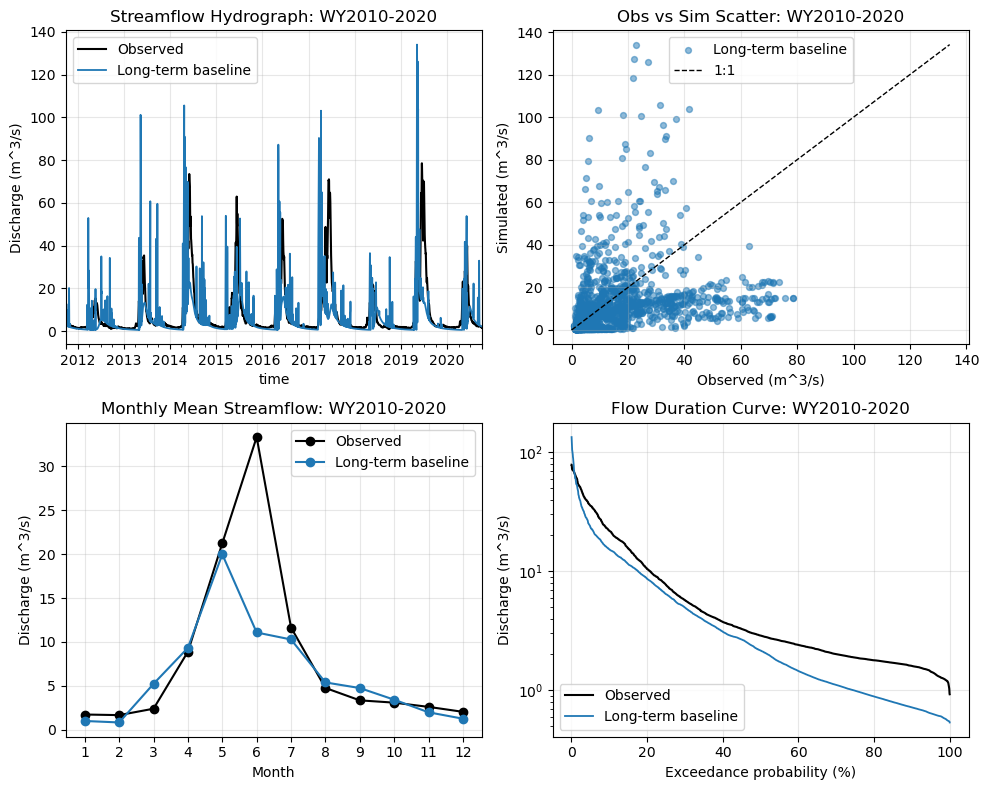

In [45]:
for window in plot_windows:
    start = window['start']
    end = window['end']
    label = window['label']

    obs_window = clip_to_window(obs_streamflow, start, end).resample('1D').mean()
    sim_windows = {
        name: clip_to_window(streamflow_daily[name], start, end).resample('1D').mean()
        for name in run_names_to_plot
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # --- top-left: daily hydrograph ---
    ax = axes[0, 0]
    obs_window.plot(ax=ax, color='black', linewidth=1.5, label='Observed')
    for name, series in sim_windows.items():
        series.plot(ax=ax, linewidth=1.3, label=name)
    ax.set_title(f'Streamflow Hydrograph: {label}')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # --- top-right: obs vs sim scatter ---
    ax = axes[0, 1]
    scatter_added = False
    for name, series in sim_windows.items():
        obs_aligned, sim_aligned = align_series(obs_window, series)
        if len(obs_aligned) == 0:
            continue
        scatter_added = True
        ax.scatter(obs_aligned, sim_aligned, alpha=0.5, s=18, label=name)
    if scatter_added:
        max_obs = max(v.max() for v in [clip_to_window(obs_window, start, end)] if len(v) > 0)
        max_sim = max(
            (s.max() for s in sim_windows.values() if s is not None and len(s) > 0),
            default=max_obs,
        )
        max_val = max(max_obs, max_sim)
        ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.0, label='1:1')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No overlapping data for scatter', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'Obs vs Sim Scatter: {label}')
    ax.set_xlabel('Observed (m^3/s)')
    ax.set_ylabel('Simulated (m^3/s)')
    ax.grid(True, alpha=0.3)

    # In 'auto' mode there is only one reservoir candidate (no side-by-side comparison),
    # so the lower panels plot a single routed line.  In 'best_of_candidates' mode both
    # the manual (prior-run) params and the freshly-optimized params are shown.
    show_both = (RESERVOIR_SELECTION_MODE == 'best_of_candidates') and USE_LINEAR_RESERVOIR

    # --- bottom-left: monthly mean streamflow ---
    ax = axes[1, 0]
    obs_monthly = obs_window.groupby(obs_window.index.month).mean()
    ax.plot(obs_monthly.index, obs_monthly.values, 'k-o', label='Observed')
    for name, series in sim_windows.items():
        monthly = series.groupby(series.index.month).mean()

        if show_both:
            if name in streamflow_daily_manual:
                manual_series = clip_to_window(streamflow_daily_manual[name], start, end)
                if manual_series is not None and len(manual_series) > 0:
                    ax.plot(
                        manual_series.groupby(manual_series.index.month).mean().index,
                        manual_series.groupby(manual_series.index.month).mean().values,
                        linestyle='--', linewidth=1.2,
                        label=f'{name} (prior-run params)',
                        marker='^',
                    )
                # calc nse and print
                    manual_nse = linear_reservoir.nse(obs_window.values, manual_series.values)
                    print(f"  Monthly mean NSE for {name} (manual params): {manual_nse:.5f}")
            if name in streamflow_daily_optimized:
                opt_series = clip_to_window(streamflow_daily_optimized[name], start, end)
                if opt_series is not None and len(opt_series) > 0:
                    ax.plot(
                        opt_series.groupby(opt_series.index.month).mean().index,
                        opt_series.groupby(opt_series.index.month).mean().values,
                        linestyle=':', linewidth=1.6,
                        label=f'{name} (optimizer params)',
                        marker='o',
                    )
                # calc nse and print
                    opt_nse = linear_reservoir.nse(obs_window.values, opt_series.values)
                    print(f"  Monthly mean NSE for {name} (optimized params): {opt_nse:.5f}")
        else:
            ax.plot(monthly.index, monthly.values, marker='o', label=name)

    ax.set_xticks(range(1, 13))
    ax.set_title(f'Monthly Mean Streamflow: {label}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # --- bottom-right: flow duration curve ---
    ax = axes[1, 1]
    obs_sorted = obs_window.sort_values(ascending=False)
    obs_rank = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted) * 100.0
    ax.semilogy(obs_rank, obs_sorted.values, color='black', linewidth=1.5, label='Observed')
    for name, series in sim_windows.items():
        sorted_series = series.sort_values(ascending=False)
        rank = np.arange(1, len(sorted_series) + 1) / len(sorted_series) * 100.0

        if show_both:
            if name in streamflow_daily_manual:
                manual_series = clip_to_window(streamflow_daily_manual[name], start, end)
                if manual_series is not None and len(manual_series) > 0:
                    manual_sorted = manual_series.sort_values(ascending=False)
                    manual_rank = np.arange(1, len(manual_sorted) + 1) / len(manual_sorted) * 100.0
                    ax.semilogy(
                        manual_rank, manual_sorted.values,
                        linestyle='--', linewidth=1.2,
                        label=f'{name} (prior-run params)',
                    )
            if name in streamflow_daily_optimized:
                opt_series = clip_to_window(streamflow_daily_optimized[name], start, end)
                if opt_series is not None and len(opt_series) > 0:
                    opt_sorted = opt_series.sort_values(ascending=False)
                    opt_rank = np.arange(1, len(opt_sorted) + 1) / len(opt_sorted) * 100.0
                    ax.semilogy(
                        opt_rank, opt_sorted.values,
                        linestyle=':', linewidth=1.6,
                        label=f'{name} (optimizer params)',
                    )
        else:
            ax.semilogy(rank, sorted_series.values, linewidth=1.3, label=name)

    ax.set_title(f'Flow Duration Curve: {label}')
    ax.set_xlabel('Exceedance probability (%)')
    ax.set_ylabel('Discharge (m^3/s)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

In [44]:
# print metrics for each run and metric window
for window_name, window in metric_windows.items():
    print(f'Metrics for window: {window_name} ({window["start"]} to {window["end"]})')
    obs_window = clip_to_window(obs_streamflow, window['start'], window['end'])
    for run_name in run_names_to_plot:
        sim_window = clip_to_window(streamflow_daily[run_name], window['start'], window['end'])
        if sim_window is None or len(sim_window) == 0:
            print(f'  {run_name}: No simulation data in this window.')
            continue
        try:
            metrics = compute_streamflow_metrics(obs_window, sim_window)
            print(f'  {run_name}: RMSE={metrics["rmse_cms"]:.2f} cms, Bias={metrics["bias_cms"]:.2f} cms, PBIAS={metrics["pbias_pct"]:.1f}%, Corr={metrics["corr"]:.3f}, NSE={metrics["nse"]:.3f}, KGE={metrics["kge"]:.3f}, logNSE={metrics["log_nse"]:.3f}')
        except ValueError as e:
            print(f'  {run_name}: Error computing metrics - {e}')

Metrics for window: Long-term baseline (2011-10-01 to 2020-09-30)
  Long-term baseline: RMSE=12.90 cms, Bias=-1.82 cms, PBIAS=-22.6%, Corr=0.424, NSE=-0.113, KGE=0.379, logNSE=0.154
Metrics for window: Target baseline (2020-10-01 to 2021-09-30)
  Long-term baseline: RMSE=6.04 cms, Bias=0.58 cms, PBIAS=13.7%, Corr=0.601, NSE=-0.426, KGE=0.361, logNSE=-0.477


## ET and SWE Comaprison

/home/dlhogan/miniforge3/envs/ess-project-env/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


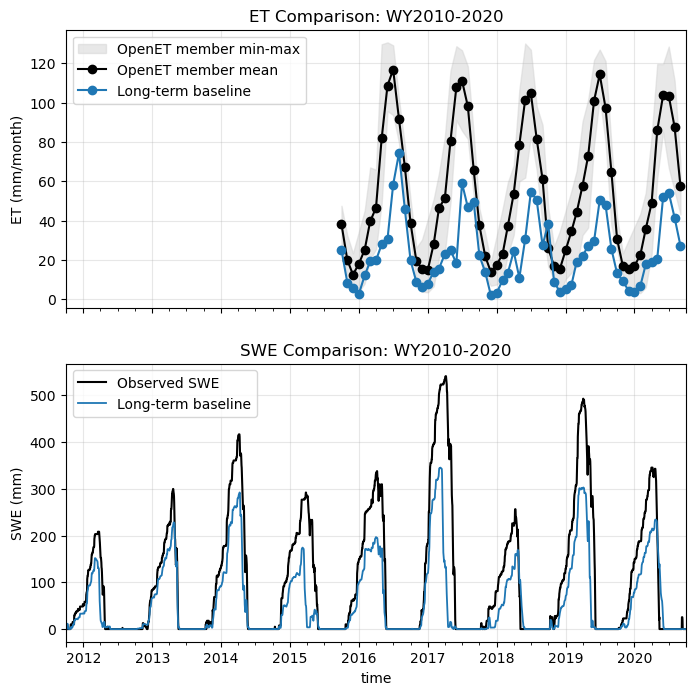

<Figure size 640x480 with 0 Axes>

In [21]:
for window in plot_windows:
    start = window['start']
    end = window['end']
    label = window['label']

    fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

    ax = axes[0]
    if obs_et_envelope is not None:
        env = clip_to_window(obs_et_envelope, start, end)
        if env is not None and len(env) > 0:
            ax.fill_between(
                env.index,
                env["et_min"].values,
                env["et_max"].values,
                color="lightgray",
                alpha=0.5,
                label="OpenET member min-max",
                zorder=1,
            )
            ax.plot(
                env.index,
                env["et_mean"].values,
                color="black",
                marker="o",
                linewidth=1.5,
                label="OpenET member mean",
                zorder=2,
            )
    elif obs_et is not None:
        clipped_obs_et = clip_to_window(obs_et, start, end)
        if len(clipped_obs_et) > 0:
            clipped_obs_et.plot(ax=ax, color='black', marker='o', label='Observed ET')
    for name, series in et_monthly.items():
        if series is not None:
            clipped_series = clip_to_window(series, start, end)
            if len(clipped_series) > 0:
                clipped_series.plot(ax=ax, marker='o', label=name)
    ax.set_title(f'ET Comparison: {label}')
    ax.set_ylabel('ET (mm/month)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    clipped_obs_swe = clip_to_window(obs_swe, start, end)
    if len(clipped_obs_swe) > 0:
        clipped_obs_swe.plot(ax=ax, color='black', linewidth=1.5, label='Observed SWE')
    for name, series in swe_daily.items():
        if series is not None:
            clipped_series = clip_to_window(series, start, end)
            if len(clipped_series) > 0:
                clipped_series.plot(ax=ax, linewidth=1.3, label=name)
    ax.set_title(f'SWE Comparison: {label}')
    ax.set_ylabel('SWE (mm)')
    ax.grid(True, alpha=0.3)

    ax.legend()
    ax.legend()   

    plt.show()

    plt.tight_layout() 

## Soil Moisture and Baseflow Comparison

In [22]:
# create instant runoff value for comparison to baseflow to create fraction
q_inst = ds_longterm['averageInstantRunoff'].squeeze().to_pandas()
q_inst.index = pd.to_datetime(q_inst.index)
q_inst = q_inst.resample('D').mean() * basin_area_m2
# 
neg_count = int((q_inst < 0).sum())
if neg_count > 0:
    print(f'Warning: found {neg_count} negative q_inst values; clipping to 0 for baseflow-fraction plotting.')
q_inst = q_inst.clip(lower=0.0)

soil_baseflow = ds_longterm['scalarSoilBaseflow'].squeeze().to_pandas() * 86400.0 * 1000.0

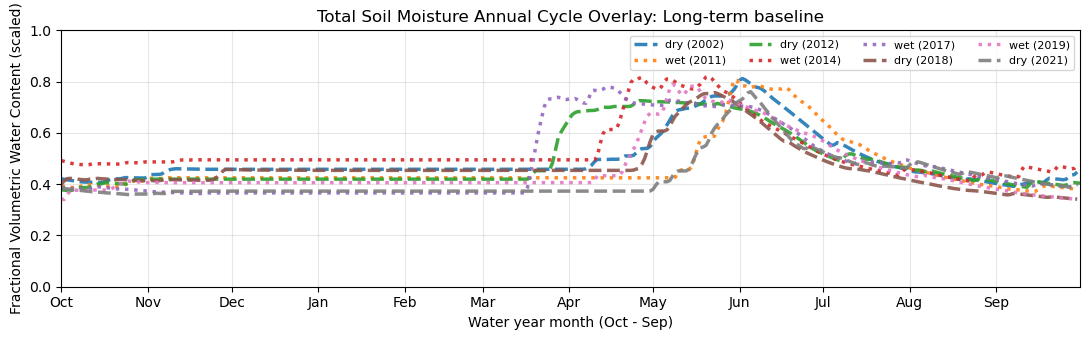

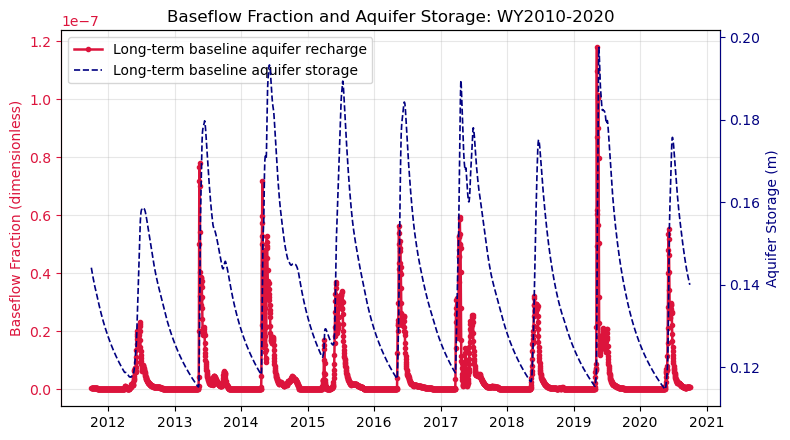

In [ ]:
# Soil moisture annual-cycle overlays by water year (Oct 1 -> Sep 30).
available_soil_runs = [
    name for name in run_names_to_plot
    if soil_moisture_daily.get(name) is not None and len(soil_moisture_daily.get(name)) > 0
]

if not available_soil_runs:
    print('No soil moisture data available for annual-cycle plotting.')
else:
    nrows = len(available_soil_runs)
    fig, axes = plt.subplots(nrows, 1, figsize=(11, 3.5 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    soil_start = min(soil_moisture_daily[name].index.min() for name in available_soil_runs)
    soil_end = max(soil_moisture_daily[name].index.max() for name in available_soil_runs)

    wy_ref_start = pd.Timestamp('2000-10-01')
    month_starts = pd.date_range(wy_ref_start, periods=12, freq='MS')
    month_ticks = ((month_starts - wy_ref_start).days + 1).tolist()
    month_labels = [d.strftime('%b') for d in month_starts]

    for ax, run_name in zip(axes, available_soil_runs):
        series = clip_to_window(soil_moisture_daily[run_name], soil_start, soil_end)
        wy_series = series.index.year + (series.index.month >= 10).astype(int)
        df = pd.DataFrame({'soil_moisture': series.values, 'water_year': wy_series}, index=series.index)

        for wy, group in df.groupby('water_year'):
            if wy in [2002, 2012, 2018, 2021]:
                lw = 2.5
                ls = '--'
                label = 'dry'
            elif wy in [2011, 2014, 2017, 2019]:
                lw = 2.5
                ls = ':'
                label = 'wet'

            else:
                continue
            wy_start = pd.Timestamp(year=int(wy) - 1, month=10, day=1)
            wy_day = (group.index.normalize() - wy_start).days + 1
            valid = (wy_day >= 1) & (wy_day <= 366)
            ax.plot(wy_day[valid], (group['soil_moisture'].values[valid]-50)/(400-50), linewidth=lw, linestyle=ls, alpha=0.9, label=label + f' ({wy})')

        ax.set_title(f'Total Soil Moisture Annual Cycle Overlay: {run_name}')
        ax.set_ylabel('Fractional Volumetric Water Content (scaled)')
        ax.set_xlim(1, 366)
        ax.set_ylim(0, 1)   
        ax.set_xticks(month_ticks)
        ax.set_xticklabels(month_labels)
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=4, fontsize=8)

    axes[-1].set_xlabel('Water year month (Oct - Sep)')
    plt.tight_layout()
    plt.show()

# Minimal baseflow fraction + aquifer storage plot by window (no conditional branches).
left_color = 'crimson'
right_color = 'navy'
run_name = run_names_to_plot[0]

for window in plot_windows:
    start = window['start']
    end = window['end']
    label = window['label']

    fig, ax = plt.subplots(1, 1, figsize=(8, 4.5), sharex=True)
    ax2 = ax.twinx()

    clipped_bf = clip_to_window(baseflow_daily[run_name].resample('ME').mean(), start, end)
    clipped_q_inst = clip_to_window(q_inst.resample('ME').mean(), start, end)
    frac = (clipped_bf / clipped_q_inst.replace(0, np.nan)).dropna()
    clipped_storage = clip_to_window(aquifer_storage_daily[run_name], start, end)
    clipped_recharge = clip_to_window(aquifer_recharge_daily[run_name], start, end)

    ax.plot(
        frac.index,
        frac.values,
        linewidth=1.8,
        marker='o',
        markersize=3,
        label=f'{run_name} baseflow fraction',
        color=left_color,
    )
    ax2.plot(
        clipped_storage.index,
        clipped_storage.values,
        linewidth=1.2,
        linestyle='--',
        label=f'{run_name} aquifer storage',
        color=right_color,
    )

    ax.set_title(f'Baseflow Fraction and Aquifer Storage: {label}')
    ax.set_ylabel('Baseflow Fraction (dimensionless)', color=left_color)
    ax2.set_ylabel('Aquifer Storage (m)', color=right_color)

    ax.tick_params(axis='y', colors=left_color)
    ax2.tick_params(axis='y', colors=right_color)
    ax.spines['left'].set_color(left_color)
    ax2.spines['right'].set_color(right_color)
    ax.grid(True, alpha=0.3)

    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc='best')

    plt.tight_layout()
    plt.show()

<Axes: xlabel='time'>

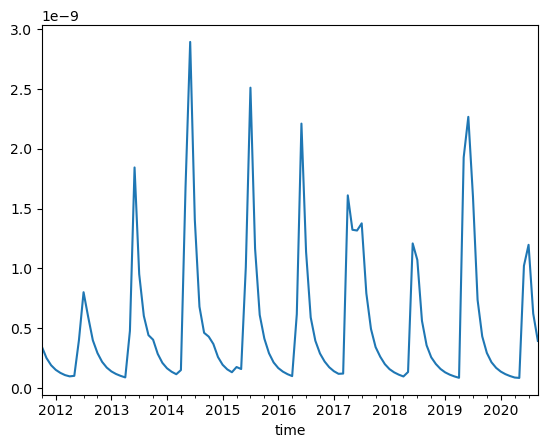

In [52]:
(clipped_bf/basin_area_m2).plot()

In [9]:
summary_rows = []
for name in run_datasets:
    summary_rows.append({
        'run': name,
        'streamflow_start': str(streamflow_daily[name].index.min().date()),
        'streamflow_end': str(streamflow_daily[name].index.max().date()),
        'et_available': et_monthly[name] is not None,
        'swe_available': swe_daily[name] is not None,
        'soil_moisture_available': soil_moisture_daily[name] is not None,
        'baseflow_available': baseflow_daily[name] is not None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('Observation availability:')
print(f'  Streamflow: {obs_streamflow_path}')
print(f'  ET: {obs_et_path if obs_et_path else "not found"}')
print(f'  SWE: {obs_swe_path if obs_swe_path else "not found"}')

,run,streamflow_start,streamflow_end,et_available,swe_available,soil_moisture_available,baseflow_available
0,Long-term baseline,2000-10-01,2021-09-30,True,True,True,True
1,Target baseline,2020-10-01,2021-09-30,True,True,True,True


Observation availability:
  Streamflow: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
  ET: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/et/openet_et_ensemble_East_monthly.csv
  SWE: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/snow/380_Butte_sntl_obs.csv
